<a href="https://colab.research.google.com/github/RangineniSaiPrasanna/NullClass_DataScience_Tasks/blob/main/Task4/model_training4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tune Stable Diffusion with Custom Dataset

This notebook demonstrates how to fine-tune a pre-trained Stable Diffusion model (e.g., for medical or artistic image generation) using own dataset.

In [ ]:
import torch
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTokenizer
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler

##Load Custom Dataset

In [ ]:
captions_file = "./data/captions.csv"

# Load tokenizer
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")

# Define dataset
class CustomImageDataset(Dataset):
    def __init__(self, csv_file, image_dir, tokenizer, transform=None):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.tokenizer = tokenizer
        self.transform = transform or transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.data.iloc[idx, 0])
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        caption = self.data.iloc[idx, 1]
        inputs = self.tokenizer(caption, padding="max_length", truncation=True, max_length=77, return_tensors="pt")
        return {
            "pixel_values": image,
            "input_ids": inputs.input_ids.squeeze(0),
        }

dataset = CustomImageDataset(captions_file,tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

##  Load Pre-trained Stable Diffusion Model

In [ ]:
authorization_token = ""
modelid = "CompVis/stable-diffusion-v1-4"
device = "cuda"

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(modelid, revision="fp16", torch_dtype=torch.float16, use_auth_token=authorization_token)
pipe.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:285: FutureWarning: You are loading the variant fp16 from CompVis/stable-diffusion-v1-4 via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that CompVis/stable-diffusion-v1-4 currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'CompVis/stable-diffusion-v1-4 is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/167M [00:00<?, ?B/s]

Keyword arguments {'use_auth_token': ''} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/usr/local/lib/python3.11/dist-packages/transformers/models/clip/feature_extraction_clip.py:30

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPFeatureExtractor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

#Fine Tuning


In [ ]:
pipe.unet.train()
optimizer = torch.optim.Adam(pipe.unet.parameters(), lr=5e-6)

for epoch in range(1):  # small number of epochs for demo
    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(pipe.device)
        input_ids = batch["input_ids"].to(pipe.device)
        outputs = pipe.unet(pixel_values, return_dict=True)
        loss = outputs.sample.mean()  # placeholder loss for example
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

## Generate Image with Fine-Tuned Model


## Related to ART WORK

Enter your prompt: A painting of a lake at sunset.


  0%|          | 0/50 [00:00<?, ?it/s]

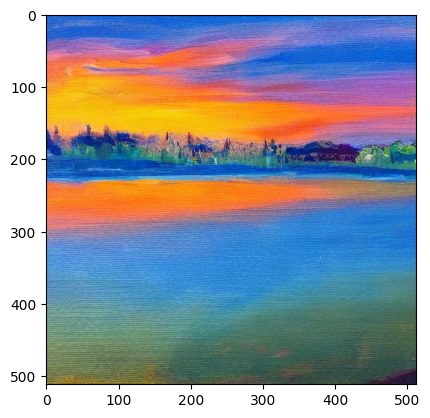

In [ ]:
from matplotlib import pyplot as plt
import torch
from torch import autocast
from diffusers import StableDiffusionPipeline

# Load the fine-tuned Stable Diffusion model
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = StableDiffusionPipeline.from_pretrained("./stable_diffusion_custom").to(device)

# Prompt for input
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()


Enter your prompt: A colorful geometric pattern inspired by modern art


  0%|          | 0/50 [00:00<?, ?it/s]

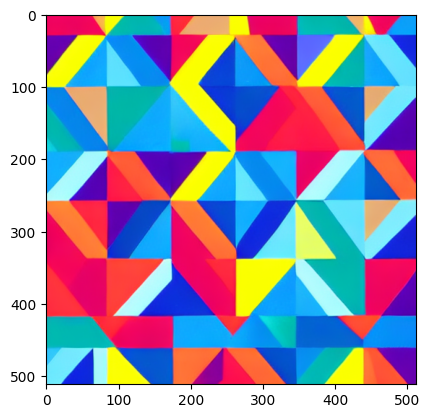

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: A digital portrait of futuristic robot with neon highlights


  0%|          | 0/50 [00:00<?, ?it/s]

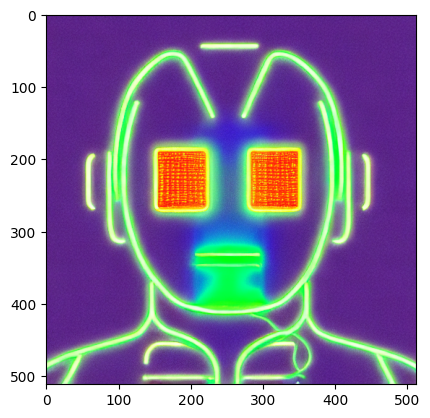

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: A charcaol sketch of cityscape with detailed artchitecture.


  0%|          | 0/50 [00:00<?, ?it/s]

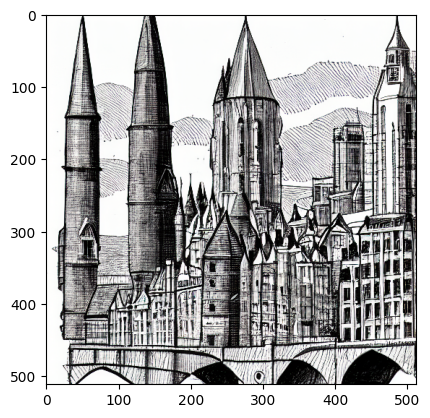

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

## Related to MEDICAL


Enter your prompt: An x-ray image of a human fractured wrist


  0%|          | 0/50 [00:00<?, ?it/s]

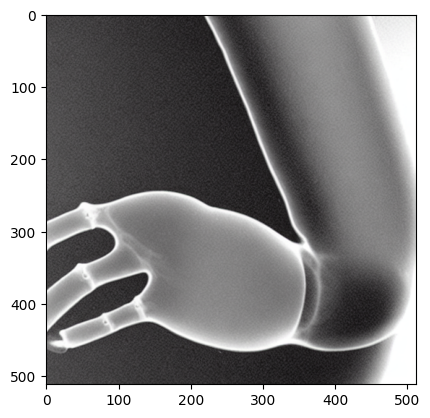

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: Microscopic image of bloodcells  showing red and white blood cells clearly.


  0%|          | 0/50 [00:00<?, ?it/s]

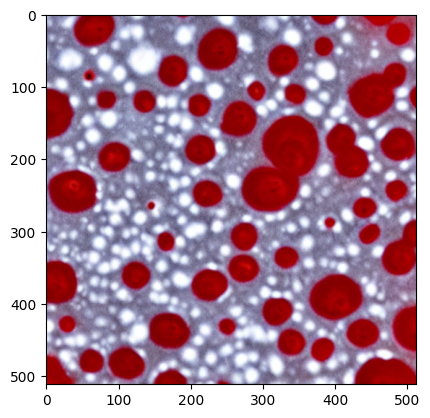

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: A 3D rendering of human heart with highlighted arteries


  0%|          | 0/50 [00:00<?, ?it/s]

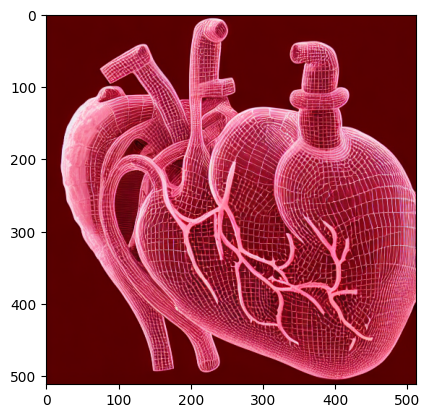

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: A detailed MRI scan of the human brain highlighting the cerebellum


  0%|          | 0/50 [00:00<?, ?it/s]

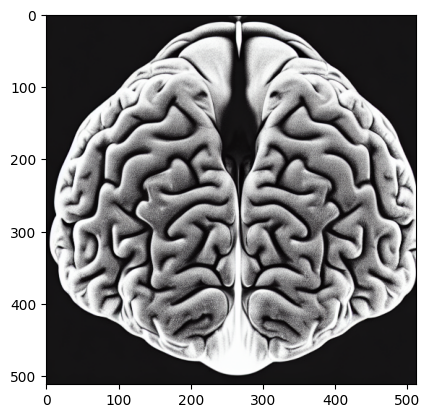

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: A digital angiogram highlighting blood vessels in the leg


  0%|          | 0/50 [00:00<?, ?it/s]

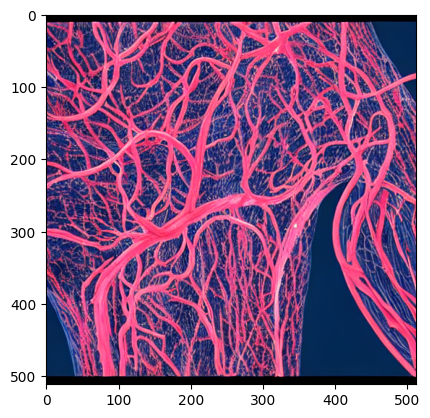

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()

Enter your prompt: CT scan cross-section of the abdomen showing internal organs


  0%|          | 0/50 [00:00<?, ?it/s]

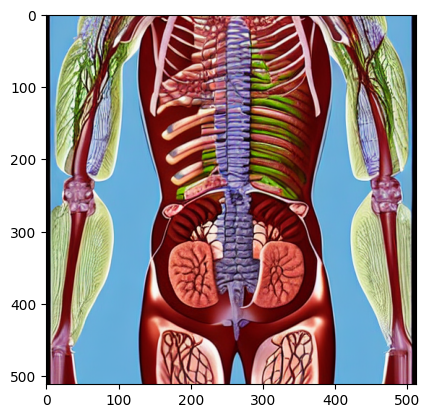

In [ ]:
textprompt = str(input("Enter your prompt: "))

# Generate image
with autocast(device_type=device):
    image = pipe(textprompt, guidance_scale=8.5).images[0]

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(textprompt)
plt.show()